# Simple Plant Detection from Multispectral Imagery

This notebook provides just the first 4 basic steps for plant detection.

## Step 1: Import Required Libraries

In [3]:
# Import required libraries
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import torch
from PIL import Image
import cv2
import leafmap.leafmap as leafmap
from skimage.measure import label, regionprops
from IPython.display import display

# Create a custom colormap for NDVI visualization
ndvi_cmap = LinearSegmentedColormap.from_list(
    'ndvi',
    [(0.0, 'red'), (0.5, 'yellow'), (1.0, 'green')],
    N=256
)

## Step 2: Define Image Loading Function

In [4]:
def load_multispectral_image(image_path, format='tif', channels=None):
    """
    Load a multispectral image from a directory structure or a single file
    """
    if channels is None:
        channels = ['R', 'G', 'B', 'NIR']

    if os.path.isdir(image_path):
        # Handle RedEdge dataset structure
        if format == 'tif':
            # For TIF format, load from reflectance-tif directory
            channel_tensors = []
            channel_files = {
                'R': 'transparent_reflectance_red.tif',
                'G': 'transparent_reflectance_green.tif',
                'B': 'transparent_reflectance_blue.tif',
                'NIR': 'transparent_reflectance_nir.tif',
                'RE': 'transparent_reflectance_rededge.tif'
            }

            for channel in channels:
                if channel not in channel_files:
                    raise ValueError(f"Channel {channel} not supported for TIF format")

                channel_path = os.path.join(image_path, channel_files[channel])

                if not os.path.exists(channel_path):
                    raise ValueError(f"Channel file {channel_path} not found")

                # Use PIL to open TIFF
                img = Image.open(channel_path)
                channel_array = np.array(img).astype(np.float32)

                # Handle single band images
                if channel_array.ndim == 2:
                    channel_tensor = torch.from_numpy(channel_array).float().unsqueeze(0)
                else:
                    # If the array is 3D with channels last, transpose to channels first
                    channel_array = np.transpose(channel_array, (2, 0, 1))
                    channel_tensor = torch.from_numpy(channel_array).float()

                channel_tensors.append(channel_tensor)

            # Stack channels
            image_tensor = torch.cat([t for t in channel_tensors])
        else:  # PNG format
            # For PNG format, load from composite-png directory
            channel_tensors = []

            for channel in channels:
                channel_path = os.path.join(image_path, f"{channel}.png")

                if not os.path.exists(channel_path):
                    raise ValueError(f"Channel file {channel_path} not found")

                img = Image.open(channel_path)
                channel_array = np.array(img).astype(np.float32)
                if channel_array.ndim == 3:
                    channel_array = channel_array[:,:,0]  # Take first channel if RGB
                channel_tensor = torch.from_numpy(channel_array).float().unsqueeze(0)

                channel_tensors.append(channel_tensor)

            # Stack channels
            image_tensor = torch.cat(channel_tensors)
    else:
        # Single file (e.g., TIFF with multiple bands)
        if image_path.lower().endswith(('.tif', '.tiff')):
            img = Image.open(image_path)
            if img.mode == 'I':  # Single band
                image_tensor = torch.from_numpy(np.array(img)).float().unsqueeze(0)
            else:
                img_array = np.array(img)
                if img_array.ndim == 3:
                    img_array = np.transpose(img_array, (2, 0, 1))
                image_tensor = torch.from_numpy(img_array).float()
        else:
            img = Image.open(image_path)
            img_array = np.array(img)
            if img_array.ndim == 3:
                img_array = np.transpose(img_array, (2, 0, 1))
            image_tensor = torch.from_numpy(img_array).float()

    # Normalize to [0, 1] range if needed
    if image_tensor.max() > 1.0:
        image_tensor /= 255.0

    return image_tensor

## Step 3: Define NDVI Vegetation Detector

In [5]:
class NDVIVegetationDetector:
    """
    Detects vegetation using NDVI (Normalized Difference Vegetation Index)
    """
    def __init__(self, threshold=0.2, red_idx=0, nir_idx=3):
        self.threshold = threshold
        self.nir_idx = nir_idx
        self.red_idx = red_idx

    def calculate_ndvi(self, image):
        """
        Calculate NDVI without thresholding
        """
        ndvi = (image[self.nir_idx] - image[self.red_idx]) / (image[self.nir_idx] + image[self.red_idx] + 1e-8)
        ndvi[torch.isnan(ndvi)] = 0
        return ndvi

    def get_vegetation_mask(self, ndvi):
        """
        Create binary vegetation mask based on NDVI threshold
        """
        return (ndvi > self.threshold).type(torch.uint8) * 255

## Step 4: Define Individual Plant Detection Function

In [6]:
def detect_individual_plants(veg_mask, min_area=10):
    """
    Detect individual plants using connected components analysis
    """
    # Ensure mask is numpy array
    if isinstance(veg_mask, torch.Tensor):
        veg_mask = veg_mask.cpu().numpy()
    
    # Make sure mask is binary
    binary_mask = (veg_mask > 0).astype(np.uint8)
    
    # Label connected components
    labeled_plants = label(binary_mask)
    
    # Get region properties
    props = regionprops(labeled_plants)
    
    # Filter small regions
    valid_labels = []
    plant_properties = []
    
    for i, prop in enumerate(props):
        if prop.area >= min_area:
            valid_labels.append(prop.label)
            plant_properties.append({
                'label': prop.label,
                'area': prop.area,
                'bbox': prop.bbox,  # (min_row, min_col, max_row, max_col)
                'centroid': prop.centroid
            })
    
    # Create filtered mask
    filtered_mask = np.isin(labeled_plants, valid_labels).astype(np.uint8)
    
    # Re-label to have consecutive labels
    final_labeled_plants = label(filtered_mask)
    
    return final_labeled_plants, plant_properties

## Step 5: Set Up Paths and Load Images

In this step, we'll set up the paths to our data and load the multispectral images.

In [7]:
# Set up paths
dataset_path = os.path.expanduser("~/Dropbox/DEV/Data/RedEdge")  # Change this to your dataset path
field_id = "002"  # Change this to the field you want to process
image_format = "tif"  # or "png"
output_dir = "plant_detection_results"

# Create output directory
os.makedirs(output_dir, exist_ok=True)

print(f"Using dataset path: {dataset_path}")
print(f"Processing field: {field_id}")
print(f"Output directory: {output_dir}")

# Set up image path
field_path = os.path.join(dataset_path, field_id)
if image_format == "tif":
    image_path = os.path.join(field_path, "reflectance-tif")
else:
    image_path = os.path.join(field_path, "composite-png")

print(f"Loading image from: {image_path}")

# Check if path exists
if not os.path.exists(image_path):
    print(f"Error: Path {image_path} does not exist")
else:
    print("Path exists, checking contents...")
    # List files in directory
    for f in os.listdir(image_path):
        print(f"  {f}")

Using dataset path: /Users/dynamicpacific/Dropbox/DEV/Data/RedEdge
Processing field: 002
Output directory: plant_detection_results
Loading image from: /Users/dynamicpacific/Dropbox/DEV/Data/RedEdge/002/reflectance-tif
Path exists, checking contents...
  transparent_reflectance_blue.tif
  transparent_reflectance_nir.tif
  transparent_reflectance_rededge.tif
  transparent_reflectance_green.tif
  transparent_reflectance_red.tif


## Step 6: Load Image and Create RGB Preview

Image loaded with shape: torch.Size([4, 6405, 6403])
Using a sample portion of the image for faster processing...
Sample image shape: torch.Size([4, 1000, 1000])


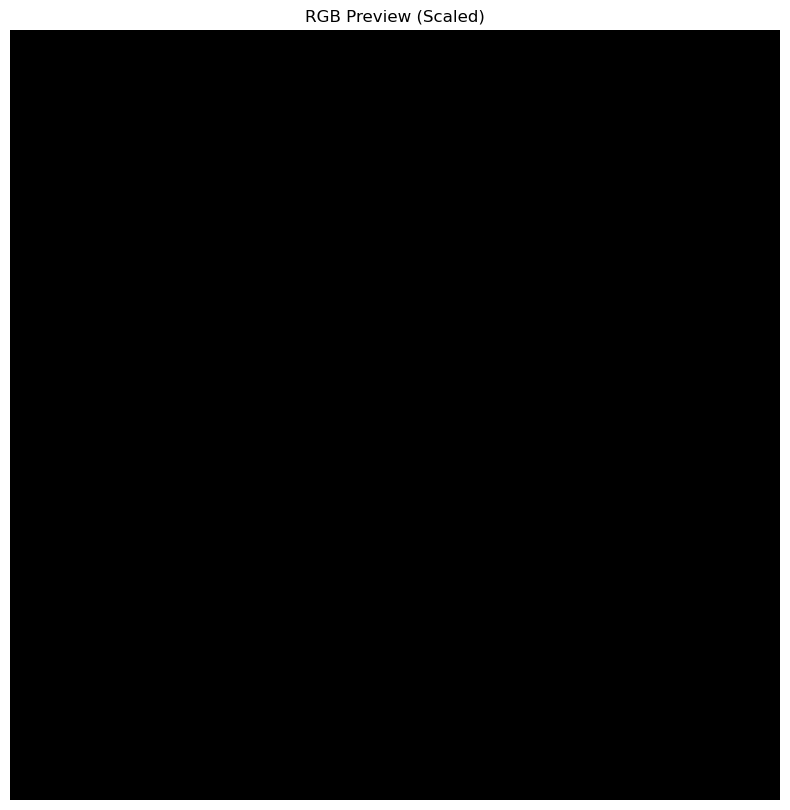

In [8]:
# Load image
image = load_multispectral_image(image_path, format=image_format)
print(f"Image loaded with shape: {image.shape}")

# Option to use a smaller portion of the image for faster processing
use_sample = True  # Set to False to process the entire image
if use_sample and image.shape[1] > 1000 and image.shape[2] > 1000:
    print("Using a sample portion of the image for faster processing...")
    # Extract a 1000x1000 sample from the center of the image
    center_h = image.shape[1] // 2
    center_w = image.shape[2] // 2
    sample_size = 1000
    image = image[:, 
                center_h - sample_size//2:center_h + sample_size//2, 
                center_w - sample_size//2:center_w + sample_size//2]
    print(f"Sample image shape: {image.shape}")

# Create RGB image for visualization
rgb_image = image[:3].permute(1, 2, 0).cpu().numpy()
if rgb_image.max() <= 1.0:
    rgb_image = (rgb_image * 255).astype(np.uint8)

# Show a small preview
preview_size = 800
if rgb_image.shape[0] > preview_size or rgb_image.shape[1] > preview_size:
    scale = preview_size / max(rgb_image.shape[0], rgb_image.shape[1])
    preview = cv2.resize(rgb_image, None, fx=scale, fy=scale)
else:
    preview = rgb_image
    
plt.figure(figsize=(10, 10))
plt.imshow(preview)
plt.title(f"RGB Preview (Scaled)")
plt.axis('off')
plt.show()

## Step 7: Calculate NDVI

In this step, we'll calculate the Normalized Difference Vegetation Index (NDVI) from the multispectral image.

Calculating NDVI...
NDVI calculated. Min: -0.259, Max: 0.681, Mean: 0.079


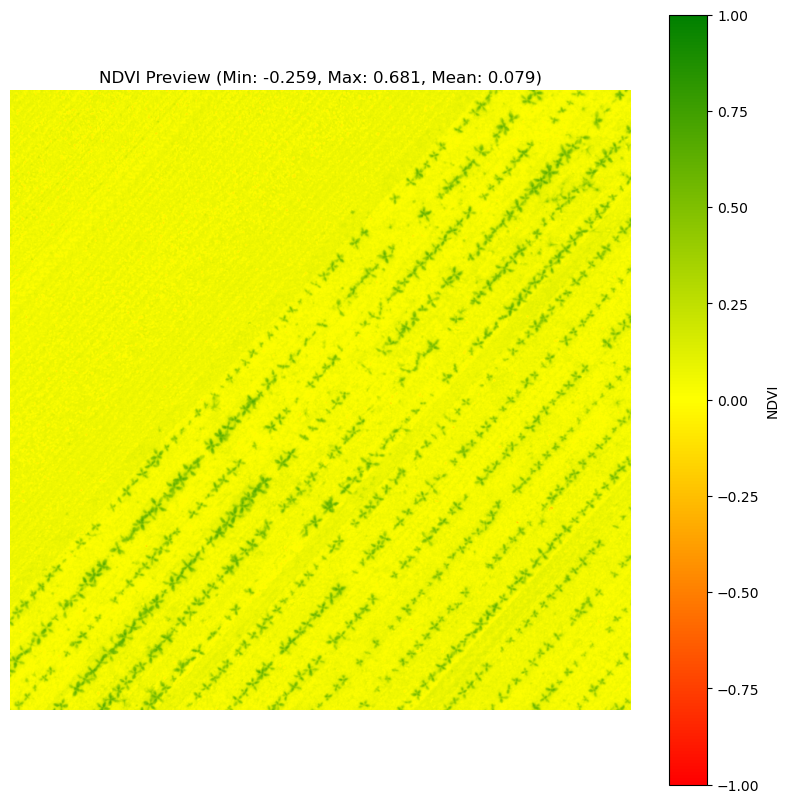

In [9]:
# Calculate NDVI
print("Calculating NDVI...")
ndvi_detector = NDVIVegetationDetector(threshold=0.2, red_idx=2, nir_idx=3)
ndvi = ndvi_detector.calculate_ndvi(image)
print(f"NDVI calculated. Min: {ndvi.min().item():.3f}, Max: {ndvi.max().item():.3f}, Mean: {ndvi.mean().item():.3f}")

# Show NDVI preview
ndvi_preview = cv2.resize(ndvi.cpu().numpy(), (preview.shape[1], preview.shape[0]))
plt.figure(figsize=(10, 10))
plt.imshow(ndvi_preview, cmap=ndvi_cmap, vmin=-1, vmax=1)
plt.colorbar(label='NDVI')
plt.title(f"NDVI Preview (Min: {ndvi.min().item():.3f}, Max: {ndvi.max().item():.3f}, Mean: {ndvi.mean().item():.3f})")
plt.axis('off')
plt.show()

## Step 8: Create Vegetation Mask

**Note:** You may want to adjust the threshold if the vegetation detection is too sensitive or not sensitive enough. Common values range from 0.1 to 0.3.

Creating vegetation mask...
Vegetation mask created. Vegetation pixels: 82950 (8.29% of image)


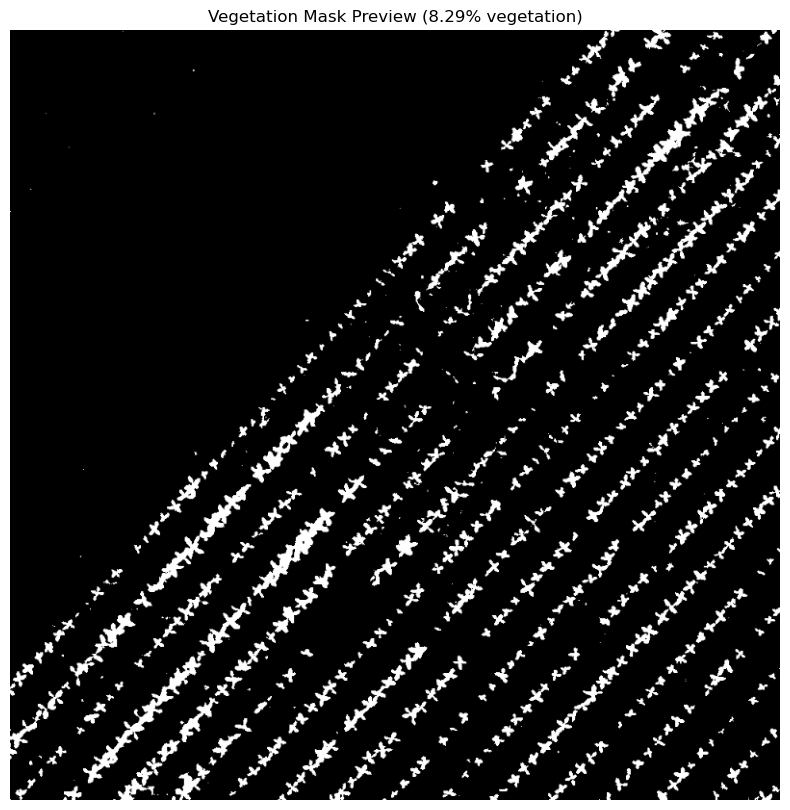

'\nndvi_detector.threshold = 0.15  # Lower for more vegetation, higher for less\nveg_mask = ndvi_detector.get_vegetation_mask(ndvi)\nveg_pixels = (veg_mask > 0).sum().item()\nveg_percentage = (veg_pixels / total_pixels) * 100\nprint(f"New vegetation mask created with threshold {ndvi_detector.threshold}")\nprint(f"Vegetation pixels: {veg_pixels} ({veg_percentage:.2f}% of image)")\n\n# Show updated vegetation mask\nveg_mask_preview = cv2.resize(veg_mask.squeeze().cpu().numpy(), (preview.shape[1], preview.shape[0]))\nplt.figure(figsize=(10, 10))\nplt.imshow(veg_mask_preview, cmap=\'gray\')\nplt.title(f"Vegetation Mask Preview (Threshold: {ndvi_detector.threshold}, {veg_percentage:.2f}% vegetation)")\nplt.axis(\'off\')\nplt.show()\n'

In [10]:

# Get vegetation mask
print("Creating vegetation mask...")
veg_mask = ndvi_detector.get_vegetation_mask(ndvi)
veg_pixels = (veg_mask > 0).sum().item()
total_pixels = veg_mask.numel()
veg_percentage = (veg_pixels / total_pixels) * 100
print(f"Vegetation mask created. Vegetation pixels: {veg_pixels} ({veg_percentage:.2f}% of image)")

# Show vegetation mask preview
veg_mask_preview = cv2.resize(veg_mask.squeeze().cpu().numpy(), (preview.shape[1], preview.shape[0]))
plt.figure(figsize=(10, 10))
plt.imshow(veg_mask_preview, cmap='gray')
plt.title(f"Vegetation Mask Preview ({veg_percentage:.2f}% vegetation)")
plt.axis('off')
plt.show()

# Try different thresholds if needed (uncomment to use)
'''
ndvi_detector.threshold = 0.15  # Lower for more vegetation, higher for less
veg_mask = ndvi_detector.get_vegetation_mask(ndvi)
veg_pixels = (veg_mask > 0).sum().item()
veg_percentage = (veg_pixels / total_pixels) * 100
print(f"New vegetation mask created with threshold {ndvi_detector.threshold}")
print(f"Vegetation pixels: {veg_pixels} ({veg_percentage:.2f}% of image)")

# Show updated vegetation mask
veg_mask_preview = cv2.resize(veg_mask.squeeze().cpu().numpy(), (preview.shape[1], preview.shape[0]))
plt.figure(figsize=(10, 10))
plt.imshow(veg_mask_preview, cmap='gray')
plt.title(f"Vegetation Mask Preview (Threshold: {ndvi_detector.threshold}, {veg_percentage:.2f}% vegetation)")
plt.axis('off')
plt.show()
'''

## Step 9: Detect Individual Plants

**Note:** This step applies connected components analysis to identify individual plants from the vegetation mask.

Detecting individual plants...
Detected 542 individual plants


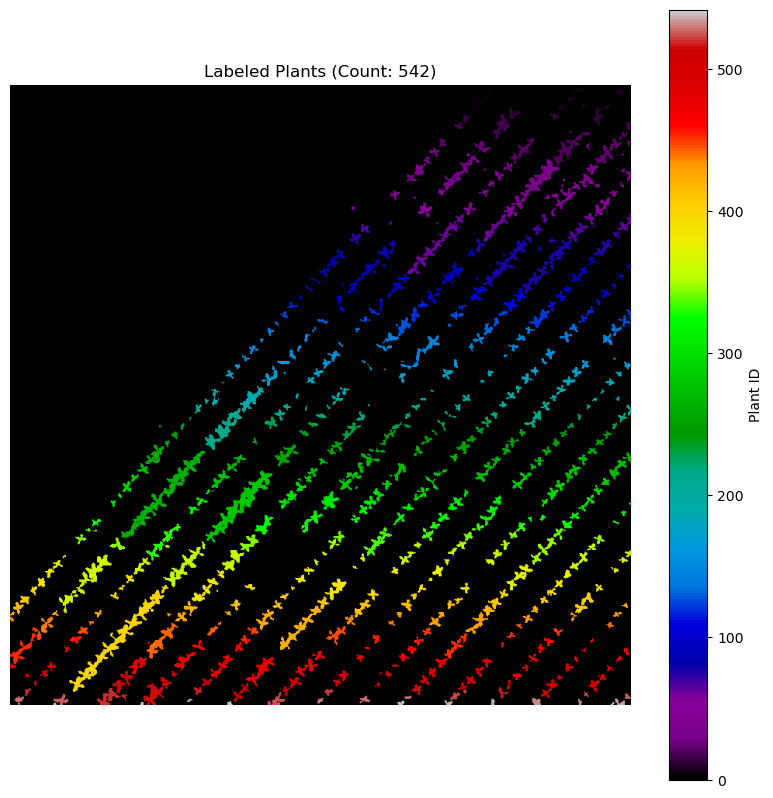

In [11]:
# Detect individual plants
print("Detecting individual plants...")
labeled_plants, plant_properties = detect_individual_plants(veg_mask, min_area=10)
print(f"Detected {len(plant_properties)} individual plants")

# Show a preview of the labeled plants
labeled_preview = cv2.resize(labeled_plants, (preview.shape[1], preview.shape[0]), interpolation=cv2.INTER_NEAREST)
plt.figure(figsize=(10, 10))
plt.imshow(labeled_preview, cmap='nipy_spectral')
plt.colorbar(label='Plant ID')
plt.title(f"Labeled Plants (Count: {len(plant_properties)})")
plt.axis('off')
plt.show()

## Step 10: Visualize Plants

In this step, we'll create visualizations of the detected plants.

Saved visualization to plant_detection_results/field_002_plants.png
RGB image: plant_detection_results/field_002_plants_rgb.png
Overlay image: plant_detection_results/field_002_plants_overlay.png

Processing complete!


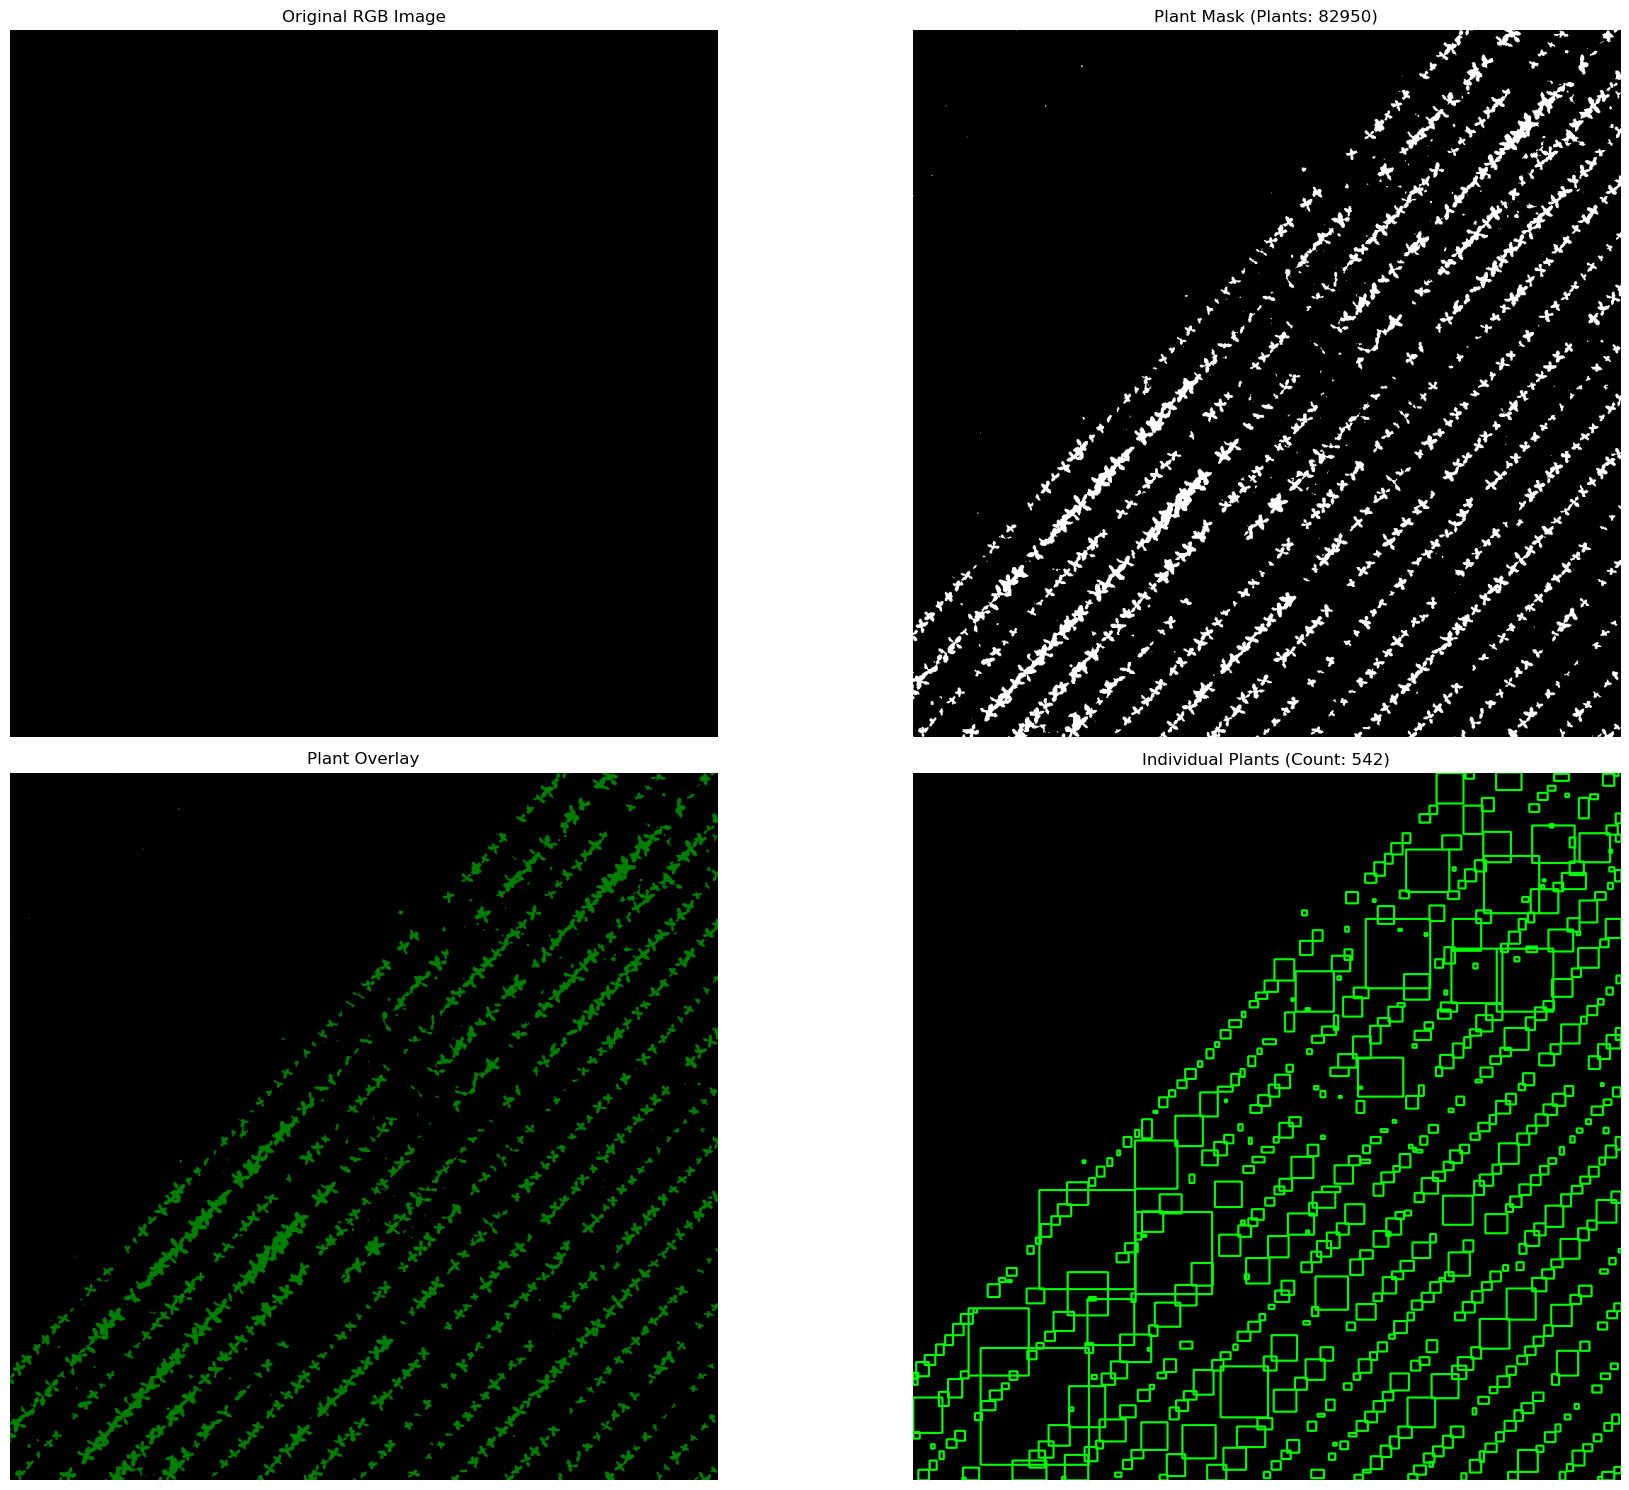

In [12]:
# Define visualization function
def visualize_plants(rgb_image, plant_mask, plant_properties=None, output_path=None):
    """
    Visualize detected plants
    
    Args:
        rgb_image: RGB image
        plant_mask: Binary plant mask
        plant_properties: Optional list of plant properties for drawing bounding boxes
        output_path: Optional path to save visualization
        
    Returns:
        Figure showing plants visualized on the RGB image
    """
    # Ensure RGB format
    if isinstance(rgb_image, torch.Tensor):
        rgb_img = rgb_image[:3].permute(1, 2, 0).cpu().numpy()
        if rgb_img.max() <= 1.0:
            rgb_img = (rgb_img * 255).astype(np.uint8)
    else:
        rgb_img = rgb_image
    
    # Create plant overlay (bright green color)
    if isinstance(plant_mask, torch.Tensor):
        plant_mask = plant_mask.cpu().numpy()
    
    # Make binary mask
    binary_mask = (plant_mask > 0).astype(np.uint8)
    
    # Create color overlay
    plant_overlay = np.zeros((*binary_mask.shape, 3), dtype=np.uint8)
    plant_overlay[binary_mask > 0] = [0, 255, 0]  # Bright green for plants
    
    # Create visualization figure
    plt.figure(figsize=(20, 15))
    
    # Plot original image
    plt.subplot(2, 2, 1)
    plt.imshow(rgb_img)
    plt.title('Original RGB Image')
    plt.axis('off')
    
    # Plot plant mask
    plt.subplot(2, 2, 2)
    plt.imshow(binary_mask, cmap='gray')
    plt.title(f'Plant Mask (Plants: {np.sum(binary_mask > 0)})')
    plt.axis('off')
    
    # Plot overlay
    plt.subplot(2, 2, 3)
    plt.imshow(rgb_img)
    plt.imshow(plant_overlay, alpha=0.5)
    plt.title('Plant Overlay')
    plt.axis('off')
    
    # Plot individual plants if properties are provided
    plt.subplot(2, 2, 4)
    plt.imshow(rgb_img)
    
    if plant_properties is not None:
        # Create copy for drawing
        img_with_boxes = rgb_img.copy()
        
        # Draw bounding boxes
        for prop in plant_properties:
            # Get bounding box coordinates
            min_row, min_col, max_row, max_col = prop['bbox']
            # Draw rectangle (OpenCV uses (x, y) format, not (row, col))
            cv2.rectangle(img_with_boxes, 
                         (min_col, min_row), (max_col, max_row), 
                         (0, 255, 0), 2)
        
        plt.imshow(img_with_boxes)
        plt.title(f'Individual Plants (Count: {len(plant_properties)})')
    else:
        # Just show the mask in color
        plt.imshow(plant_overlay)
        plt.title('Plant Overlay')
    
    plt.axis('off')
    
    plt.tight_layout()
    
    if output_path:
        plt.savefig(output_path, dpi=300)
        
        # Also save individual files for leafmap split view
        base_path = os.path.splitext(output_path)[0]
        
        # Save RGB
        rgb_path = f"{base_path}_rgb.png"
        cv2.imwrite(rgb_path, cv2.cvtColor(rgb_img, cv2.COLOR_RGB2BGR))
        
        # Save plant overlay
        overlay_path = f"{base_path}_overlay.png"
        overlay_img = rgb_img.copy()
        overlay_img[binary_mask > 0] = (0, 255, 0)  # Pure green where plants are
        cv2.imwrite(overlay_path, cv2.cvtColor(overlay_img, cv2.COLOR_RGB2BGR))
        
        print(f"Saved visualization to {output_path}")
        print(f"RGB image: {rgb_path}")
        print(f"Overlay image: {overlay_path}")
        
        return rgb_path, overlay_path
    
    plt.show()
    return None

# Create and save visualizations
output_path = os.path.join(output_dir, f"field_{field_id}_plants.png")
rgb_path, overlay_path = visualize_plants(
    rgb_image, 
    veg_mask, 
    plant_properties, 
    output_path
)

print("\nProcessing complete!")

## Step 11: Create Split Map Visualization

In this step, we'll create a split map visualization that allows easy comparison between the original image and the plant detection overlay.

Creating side-by-side visualization...


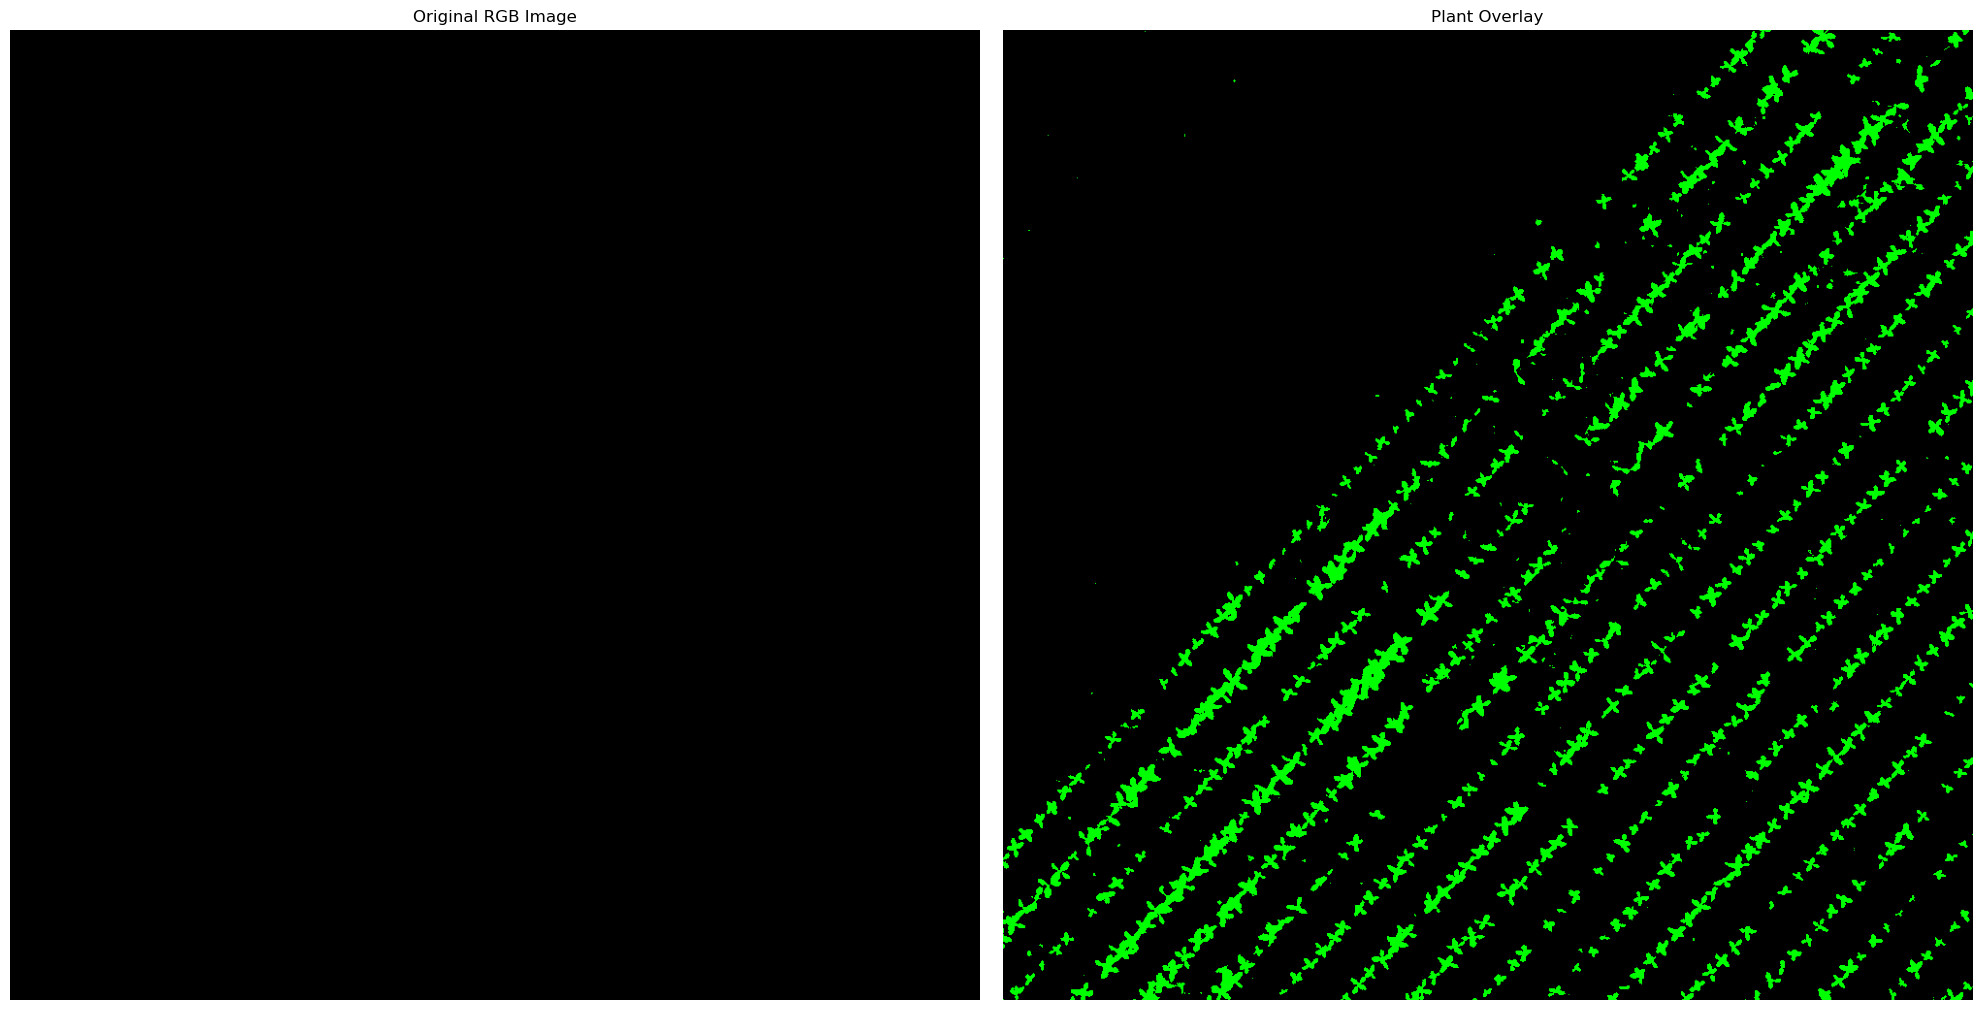

In [16]:
# Alternative to split map visualization - side by side comparison
try:
    print("Creating side-by-side visualization...")
    
    # Load the images
    rgb_img = cv2.imread(rgb_path)
    rgb_img = cv2.cvtColor(rgb_img, cv2.COLOR_BGR2RGB)
    
    overlay_img = cv2.imread(overlay_path)
    overlay_img = cv2.cvtColor(overlay_img, cv2.COLOR_BGR2RGB)
    
    # Create a figure for side-by-side comparison
    plt.figure(figsize=(20, 10))
    
    # Original image
    plt.subplot(1, 2, 1)
    plt.imshow(rgb_img)
    plt.title('Original RGB Image')
    plt.axis('off')
    
    # Overlay image
    plt.subplot(1, 2, 2)
    plt.imshow(overlay_img)
    plt.title('Plant Overlay')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print(f"Error creating side-by-side visualization: {e}")

## Step 12: Extract Individual Plants (Optional)

**Note:** This step will save each detected plant as a separate image file.

In [20]:
# Define function to create GeoJSON for plants with proper georeferencing
def create_plant_geojson(plant_properties, output_dir, tif_path):
    """
    Create a GeoJSON file for the extracted plants using proper georeferencing from TIF
    
    Args:
        plant_properties: List of plant properties
        output_dir: Directory to save the GeoJSON file
        tif_path: Path to the georeferenced TIF file
        
    Returns:
        Path to the saved GeoJSON file and center coordinates
    """
    import json
    from datetime import datetime
    import rasterio
    from rasterio.warp import transform_point
    import pyproj
    
    # Extract georeferencing from the TIF file
    with rasterio.open(tif_path) as src:
        # Get the transformation and coordinate reference system
        transform = src.transform
        crs = src.crs
        
        print(f"Source CRS: {crs}")
        print(f"Transform: {transform}")
        
        # Create a transformer to convert from UTM to WGS84 (for Folium)
        utm_to_wgs84 = pyproj.Transformer.from_crs(crs, "EPSG:4326", always_xy=True)
        
        # Create features list
        features = []
        
        # Process each plant
        for i, prop in enumerate(plant_properties):
            # Get centroid in pixel coordinates
            row, col = prop['centroid']
            
            # Convert pixel to UTM coordinates using the image's geotransform
            x, y = rasterio.transform.xy(transform, row, col)
            
            # Convert UTM to WGS84 (longitude, latitude)
            lon, lat = utm_to_wgs84.transform(x, y)
            
            # Create GeoJSON feature (using WGS84 coordinates)
            feature = {
                "type": "Feature",
                "geometry": {
                    "type": "Point",
                    "coordinates": [lon, lat]
                },
                "properties": {
                    "id": i,
                    "plant_id": prop['label'],
                    "area": prop['area'],
                    "bbox": [int(x) for x in prop['bbox']],
                    "centroid_px": [float(row), float(col)],
                    "utm_coords": [float(x), float(y)]
                }
            }
            
            features.append(feature)
        
        # Get center for the map
        center_row = src.height / 2
        center_col = src.width / 2
        center_x, center_y = rasterio.transform.xy(transform, center_row, center_col)
        center_lon, center_lat = utm_to_wgs84.transform(center_x, center_y)
        center_coords = [center_lon, center_lat]
        
        # Create GeoJSON structure
        geojson = {
            "type": "FeatureCollection",
            "name": f"Plants from field {field_id}",
            "features": features,
            "properties": {
                "created": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
                "plant_count": len(features),
                "center": center_coords,
                "original_crs": str(crs),
                "original_bounds": {
                    "utm": {
                        "east": src.bounds.left,
                        "west": src.bounds.right,
                        "north": src.bounds.top,
                        "south": src.bounds.bottom
                    }
                }
            }
        }
        
        # Save to file
        geojson_path = os.path.join(output_dir, f"field_{field_id}_plants.geojson")
        with open(geojson_path, 'w') as f:
            json.dump(geojson, f, indent=2)
        
        print(f"Created GeoJSON file with {len(features)} plants: {geojson_path}")
        return geojson_path, center_coords

# Define function to display plants on a map with proper attribution
def display_plants_on_map(geojson_path, center_coords):
    """
    Display plants on an interactive map
    
    Args:
        geojson_path: Path to the GeoJSON file
        center_coords: Center coordinates [longitude, latitude] for the map
    """
    import folium
    import json
    
    # Load GeoJSON
    with open(geojson_path, 'r') as f:
        geojson_data = json.load(f)
    
    # Create map centered on the field
    m = folium.Map(
        location=[center_coords[1], center_coords[0]], 
        zoom_start=19,
        control_scale=True
    )
    
    # Add satellite imagery with proper attribution
    folium.TileLayer(
        tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
        attr="Esri World Imagery",
        name="Satellite"
    ).add_to(m)
    
    # Style function for GeoJSON
    def style_function(feature):
        return {
            'fillColor': '#00ff00',
            'color': '#00ff00',
            'weight': 1,
            'fillOpacity': 0.7
        }
    
    # Add GeoJSON layer
    folium.GeoJson(
        geojson_data,
        name="Plants",
        style_function=style_function,
        marker=folium.CircleMarker(radius=3, fill_color="#00ff00", color="#00ff00", weight=1),
        tooltip=folium.features.GeoJsonTooltip(
            fields=['id', 'plant_id', 'area'],
            aliases=['ID', 'Plant ID', 'Area (pixels)'],
            localize=True
        )
    ).add_to(m)
    
    # Add marker for center
    folium.Marker(
        location=[center_coords[1], center_coords[0]],
        popup="Field Center",
        icon=folium.Icon(color="red", icon="info-sign")
    ).add_to(m)
    
    # Add tile layer control
    folium.TileLayer(
        'cartodbpositron', 
        name='Light Map', 
        attr='CartoDB Positron'
    ).add_to(m)
    
    folium.TileLayer(
        'openstreetmap', 
        name='OpenStreetMap',
        attr='OpenStreetMap'
    ).add_to(m)
    
    folium.LayerControl().add_to(m)
    
    # Display map
    display(m)
    
    return m

# Create GeoJSON and display map
try:
    print("Creating GeoJSON for plants with proper georeferencing...")
    
    # Path to the georeferenced TIF file
    tif_path = os.path.join(image_path, "transparent_reflectance_nir.tif")
    
    if not os.path.exists(tif_path):
        raise FileNotFoundError(f"TIF file not found at {tif_path}")
    
    # Make sure needed packages are installed
    try:
        import rasterio
        import pyproj
    except ImportError:
        print("Installing required packages: rasterio, pyproj")
        !pip install rasterio pyproj
        import rasterio
        import pyproj
    
    # Create GeoJSON
    geojson_path, center_coords = create_plant_geojson(plant_properties, output_dir, tif_path)
    
    # Display on map
    print("Displaying plants on map...")
    m = display_plants_on_map(geojson_path, center_coords)
    
    # Save map as HTML
    map_path = os.path.join(output_dir, f"field_{field_id}_plant_map.html")
    m.save(map_path)
    print(f"Map saved as: {map_path}")
    
except Exception as e:
    import traceback
    print(f"Error creating plant map: {e}")
    traceback.print_exc()

Creating GeoJSON for plants with proper georeferencing...
Error creating plant map: cannot import name 'transform_point' from 'rasterio.warp' (/opt/homebrew/Caskroom/miniforge/base/envs/crop-counter/lib/python3.10/site-packages/rasterio/warp.py)


Traceback (most recent call last):
  File "/var/folders/cr/vqtxh7m93x3b4vqrzyk50p8c0000gn/T/ipykernel_16730/2383903569.py", line 201, in <module>
    geojson_path, center_coords = create_plant_geojson(plant_properties, output_dir, tif_path)
  File "/var/folders/cr/vqtxh7m93x3b4vqrzyk50p8c0000gn/T/ipykernel_16730/2383903569.py", line 17, in create_plant_geojson
    from rasterio.warp import transform_point
ImportError: cannot import name 'transform_point' from 'rasterio.warp' (/opt/homebrew/Caskroom/miniforge/base/envs/crop-counter/lib/python3.10/site-packages/rasterio/warp.py)


In [21]:
# Define function to create GeoJSON for plants with proper georeferencing
def create_plant_geojson(plant_properties, output_dir, tif_path):
    """
    Create a GeoJSON file for the extracted plants using proper georeferencing from TIF
    
    Args:
        plant_properties: List of plant properties
        output_dir: Directory to save the GeoJSON file
        tif_path: Path to the georeferenced TIF file
        
    Returns:
        Path to the saved GeoJSON file and center coordinates
    """
    import json
    from datetime import datetime
    import rasterio
    import pyproj
    
    # Extract georeferencing from the TIF file
    with rasterio.open(tif_path) as src:
        # Get the transformation and coordinate reference system
        transform = src.transform
        crs = src.crs
        
        print(f"Source CRS: {crs}")
        print(f"Transform: {transform}")
        
        # Create a transformer to convert from UTM to WGS84 (for Folium)
        utm_to_wgs84 = pyproj.Transformer.from_crs(crs, "EPSG:4326", always_xy=True)
        
        # Create features list
        features = []
        
        # Process each plant
        for i, prop in enumerate(plant_properties):
            # Get centroid in pixel coordinates
            row, col = prop['centroid']
            
            # Convert pixel to UTM coordinates using the image's geotransform
            x, y = rasterio.transform.xy(transform, row, col)
            
            # Convert UTM to WGS84 (longitude, latitude)
            lon, lat = utm_to_wgs84.transform(x, y)
            
            # Create GeoJSON feature (using WGS84 coordinates)
            feature = {
                "type": "Feature",
                "geometry": {
                    "type": "Point",
                    "coordinates": [lon, lat]
                },
                "properties": {
                    "id": i,
                    "plant_id": prop['label'],
                    "area": prop['area'],
                    "bbox": [int(x) for x in prop['bbox']],
                    "centroid_px": [float(row), float(col)],
                    "utm_coords": [float(x), float(y)]
                }
            }
            
            features.append(feature)
        
        # Get center for the map
        center_row = src.height / 2
        center_col = src.width / 2
        center_x, center_y = rasterio.transform.xy(transform, center_row, center_col)
        center_lon, center_lat = utm_to_wgs84.transform(center_x, center_y)
        center_coords = [center_lon, center_lat]
        
        # Create GeoJSON structure
        geojson = {
            "type": "FeatureCollection",
            "name": f"Plants from field {field_id}",
            "features": features,
            "properties": {
                "created": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
                "plant_count": len(features),
                "center": center_coords,
                "original_crs": str(crs),
                "original_bounds": {
                    "utm": {
                        "east": src.bounds.left,
                        "west": src.bounds.right,
                        "north": src.bounds.top,
                        "south": src.bounds.bottom
                    }
                }
            }
        }
        
        # Save to file
        geojson_path = os.path.join(output_dir, f"field_{field_id}_plants.geojson")
        with open(geojson_path, 'w') as f:
            json.dump(geojson, f, indent=2)
        
        print(f"Created GeoJSON file with {len(features)} plants: {geojson_path}")
        return geojson_path, center_coords

# Define function to display plants on a map with proper attribution
def display_plants_on_map(geojson_path, center_coords):
    """
    Display plants on an interactive map
    
    Args:
        geojson_path: Path to the GeoJSON file
        center_coords: Center coordinates [longitude, latitude] for the map
    """
    import folium
    import json
    
    # Load GeoJSON
    with open(geojson_path, 'r') as f:
        geojson_data = json.load(f)
    
    # Create map centered on the field
    m = folium.Map(
        location=[center_coords[1], center_coords[0]], 
        zoom_start=19,
        control_scale=True
    )
    
    # Add satellite imagery with proper attribution
    folium.TileLayer(
        tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
        attr="Esri World Imagery",
        name="Satellite"
    ).add_to(m)
    
    # Add GeoJSON layer
    folium.GeoJson(
        geojson_data,
        name="Plants",
        marker=folium.CircleMarker(radius=3, fill_color="#00ff00", color="#00ff00", weight=1),
        tooltip=folium.features.GeoJsonTooltip(
            fields=['id', 'plant_id', 'area'],
            aliases=['ID', 'Plant ID', 'Area (pixels)'],
            localize=True
        )
    ).add_to(m)
    
    # Add marker for center
    folium.Marker(
        location=[center_coords[1], center_coords[0]],
        popup="Field Center",
        icon=folium.Icon(color="red", icon="info-sign")
    ).add_to(m)
    
    # Add tile layer control
    folium.TileLayer(
        'cartodbpositron', 
        name='Light Map', 
        attr='CartoDB Positron'
    ).add_to(m)
    
    folium.TileLayer(
        'openstreetmap', 
        name='OpenStreetMap',
        attr='OpenStreetMap'
    ).add_to(m)
    
    folium.LayerControl().add_to(m)
    
    # Display map
    display(m)
    
    return m

# Create GeoJSON and display map
try:
    print("Creating GeoJSON for plants with proper georeferencing...")
    
    # Path to the georeferenced TIF file
    tif_path = os.path.join(image_path, "transparent_reflectance_nir.tif")
    
    if not os.path.exists(tif_path):
        raise FileNotFoundError(f"TIF file not found at {tif_path}")
    
    # Make sure needed packages are installed
    try:
        import rasterio
        import pyproj
    except ImportError:
        print("Installing required packages: rasterio, pyproj")
        !pip install rasterio pyproj
        import rasterio
        import pyproj
    
    # Create GeoJSON
    geojson_path, center_coords = create_plant_geojson(plant_properties, output_dir, tif_path)
    
    # Display on map
    print("Displaying plants on map...")
    m = display_plants_on_map(geojson_path, center_coords)
    
    # Save map as HTML
    map_path = os.path.join(output_dir, f"field_{field_id}_plant_map.html")
    m.save(map_path)
    print(f"Map saved as: {map_path}")
    
except Exception as e:
    import traceback
    print(f"Error creating plant map: {e}")
    traceback.print_exc()

Creating GeoJSON for plants with proper georeferencing...
Source CRS: EPSG:32632
Transform: | 0.01, 0.00, 357762.55|
| 0.00,-0.01, 5608952.61|
| 0.00, 0.00, 1.00|
Created GeoJSON file with 542 plants: plant_detection_results/field_002_plants.geojson
Displaying plants on map...


Map saved as: plant_detection_results/field_002_plant_map.html
